Cambios realizados por DR 2026/09/15:
- Se ajustaron textos markdown en todo el notebook (mejorable totalmente)
- Se corrigió apartado de modelo supervisado, donde estabamos seleccionando modelo con grupo test, y lo indicado en el modulo es que se utiliza entrenamiento para este fin. Test es solo para validar y comparar metrica de modelo seleccionado.
- Se agrega validación cruzada en train.
- Se agrega validación con grupo test, revisando metricas, matriz y variables mas relevantes.
- Se agrega comparativa trian vs test.

Pendiente:
- Comentar nuevas celdas (Supervisado)


# Trabajo Final: Aprendizaje Supervisado y No Supervisado

**Ramo:** Aprendizaje estadístico y computacional

**Integrantes:**
- Ana Chia Koo
- Daniel Gonzalez
- Betty Rabanal
- Diego Rojas
- Alberto Tiahuallpa

**Tema a tratar**: Predecir el nivel de ingreso de paises a partir de variables socioeconómicas, y validar la agrupación de paises en clusters, tomando una base de indicadores del Banco Mundial disponible en su web.

## Introducción

En este trabajo se utilizaron indicadores socioeconómicos de los países del mundo, obtenidos desde la API del Banco Mundial para el año 2022. Se propusieron 2 objetivos:
- Predecir el nivel de ingreso de un país a partir de sus características de desarrollo, usando aprendizaje supervisado.
- Descubrir si al agrupar los países solo por esas características, sin mirar su ingreso, aparecen perfiles que coincidan o no con la clasificación oficial del Banco Mundial.

El nivel de ingreso lo define el Banco Mundial a partir del ingreso nacional bruto per cápita, por lo que las variables monetarias quedan fuera del modelo para evitar circularidad. Algunos indicadores no monetarios utilizados se relacionan con salud, demografía y conectividad.

## Objetivos

**Objetivo general**
Identificar las características socioeconómicas asociadas al nivel de ingreso de los países y contrastar la clasificación oficial de ingreso del Banco Mundial con agrupamientos obtenidos directamente de los datos.

**Objetivos específicos**

- Caracterizar los países mediante un análisis exploratorio, tratando datos faltantes y valores atípicos.
- Entrenar y comparar modelos de clasificación para predecir el grupo de ingreso e identificar las variables más influyentes.
- Construir agrupamientos de países sin usar la variable respuesta y contrastarlos con la clasificación oficial de ingreso.

## 1. Librerías

Se importan todas las librerías que se utilizarán a lo largo del trabajo.

In [53]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage




pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

## 2. Extracción de los datos desde la API del Banco Mundial

Cada indicador es una llamada aparte a la API, identificado por su código. Se definió una función que trae un indicador para todos los países en un año y devuelve un DataFrame con el código ISO de 3 letras y el valor.

In [30]:
def traer_indicador(codigo, nombre, anio=2022):
    url = f"http://api.worldbank.org/v2/country/all/indicator/{codigo}"
    params = {"format": "json", "date": anio, "per_page": 1000}
    rpta = requests.get(url, params=params).json()[1]
    df = pd.json_normalize(rpta)[["countryiso3code", "value"]]
    # Los agregados regionales llegan con código vacío; los quito para que el
    # merge por país no genere un producto cartesiano entre indicadores.
    df = df[df["countryiso3code"].str.len() == 3]
    return df.rename(columns={"value": nombre})

# Indicadores no monetarios que uso como covariables
indicadores = {
    "SP.DYN.LE00.IN":     "Esperanza_vida",
    "SP.DYN.TFRT.IN":     "Fecundidad",
    "SP.URB.TOTL.IN.ZS":  "Urbana_pct",
    "IT.NET.USER.ZS":     "Internet_pct",
    "SH.DYN.MORT":        "Mortalidad_u5",
    "SH.XPD.CHEX.GD.ZS":  "Gasto_salud_pctPIB",
    "EG.ELC.ACCS.ZS":     "Acceso_electricidad_pct",
    "SP.POP.TOTL":        "Poblacion",
    "NY.GDP.PCAP.CD":     "PIB_per_capita",
}

frames = [traer_indicador(cod, nom) for cod, nom in indicadores.items()]
print("Indicadores descargados:", len(frames))

Indicadores descargados: 9


Se unieron todos los indicadores en una sola tabla usando el código ISO del país como llave.

In [31]:
from functools import reduce
df = reduce(lambda a, b: a.merge(b, on="countryiso3code", how="outer"), frames)
print(df.shape)
df.head()

(260, 10)


,countryiso3code,Esperanza_vida,Fecundidad,Urbana_pct,Internet_pct,Mortalidad_u5,Gasto_salud_pctPIB,Acceso_electricidad_pct,Poblacion,PIB_per_capita
0,ABW,76.23,1.61,61.88,NaN,NaN,NaN,99.90,"107,310.00","31,000.57"
1,AFE,64.49,4.29,37.36,26.80,63.21,5.57,48.74,"731,821,393.00","1,675.90"
2,AFG,65.62,4.93,25.39,15.87,56.80,23.09,85.30,"40,578,842.00",357.26
3,AFW,57.98,4.56,51.70,37.50,99.28,4.17,55.59,"496,366,058.00","2,143.07"
4,AGO,64.25,5.21,69.05,35.84,51.90,2.60,48.50,"35,635,029.00","3,598.54"


La variable respuesta, el nivel de ingreso, no viene en los indicadores. Para lograrlo, se extrae del endpoint de países, que además trae la región. Ese endpoint mezcla países reales con agregados regionales, así que se extrae la región para filtrarlos después.

In [32]:
url_paises = "http://api.worldbank.org/v2/country"
rpta = requests.get(url_paises, params={"format": "json", "per_page": 400}).json()[1]
meta = pd.json_normalize(rpta)[["id", "name", "region.value", "incomeLevel.id", "incomeLevel.value"]]
meta = meta.rename(columns={"id": "countryiso3code", "name": "Pais",
                            "region.value": "Region",
                            "incomeLevel.id": "Ingreso_id",
                            "incomeLevel.value": "Ingreso"})
df = df.merge(meta, on="countryiso3code", how="left")
print(df.shape)
df[["countryiso3code", "Pais", "Region", "Ingreso"]].head()

(260, 14)


,countryiso3code,Pais,Region,Ingreso
0,ABW,Aruba,Latin America & Caribbean,High income
1,AFE,Africa Eastern and Southern,Aggregates,Aggregates
2,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,AFW,Africa Western and Central,Aggregates,Aggregates
4,AGO,Angola,Sub-Saharan Africa,Lower middle income


Luego, se filran los agregados. Los agregados regionales tienen la región marcada como "Aggregates" y el nivel de ingreso como "NA", así que nos quedamos solo con los países reales.

In [33]:
antes = df.shape[0]
df = df[(df["Region"] != "Aggregates") & (df["Ingreso_id"] != "NA")].copy()
df = df.set_index("Pais")
print(f"De {antes} filas quedaron {df.shape[0]} países reales")
df["Ingreso"].value_counts()

De 260 filas quedaron 217 países reales


,count
Ingreso,
High income,86
Upper middle income,59
Lower middle income,47
Low income,25


## 3. Análisis exploratorio de datos

Se revisa la estructura, estadísticos y los datos faltantes.

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 217 entries, Aruba to Zimbabwe
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   countryiso3code          217 non-null    object 
 1   Esperanza_vida           217 non-null    float64
 2   Fecundidad               217 non-null    float64
 3   Urbana_pct               217 non-null    float64
 4   Internet_pct             182 non-null    float64
 5   Mortalidad_u5            196 non-null    float64
 6   Gasto_salud_pctPIB       192 non-null    float64
 7   Acceso_electricidad_pct  215 non-null    float64
 8   Poblacion                217 non-null    float64
 9   PIB_per_capita           209 non-null    float64
 10  Region                   217 non-null    object 
 11  Ingreso_id               217 non-null    object 
 12  Ingreso                  217 non-null    object 
dtypes: float64(9), object(4)
memory usage: 23.7+ KB


In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Esperanza_vida,217.00,73.11,7.94,18.82,67.79,74.21,78.53,85.75
Fecundidad,217.00,2.41,1.22,0.68,1.51,1.95,3.17,6.25
Urbana_pct,217.00,62.35,23.33,14.69,42.73,63.31,81.16,100.00
Internet_pct,182.00,70.24,25.27,7.14,57.00,78.78,89.50,100.00
Mortalidad_u5,196.00,27.21,38.87,1.40,6.17,14.90,38.80,424.60
Gasto_salud_pctPIB,192.00,6.83,3.37,1.77,4.33,6.55,8.68,23.09
Acceso_electricidad_pct,215.00,87.49,23.16,8.40,86.50,100.00,100.00,100.00
Poblacion,217.00,"36,706,746.19","141,528,692.84","9,992.00","821,637.00","6,664,449.00","26,018,721.00","1,425,423,212.00"
PIB_per_capita,209.00,"21,200.87","31,131.45",301.83,"2,899.16","7,655.59","28,360.30","226,052.06"


Se cuantifican los datos faltantes por variable.

Internet_pct               35
Gasto_salud_pctPIB         25
Mortalidad_u5              21
PIB_per_capita              8
Acceso_electricidad_pct     2
Urbana_pct                  0
Fecundidad                  0
Esperanza_vida              0
countryiso3code             0
Poblacion                   0
Region                      0
Ingreso_id                  0
Ingreso                     0
dtype: int64


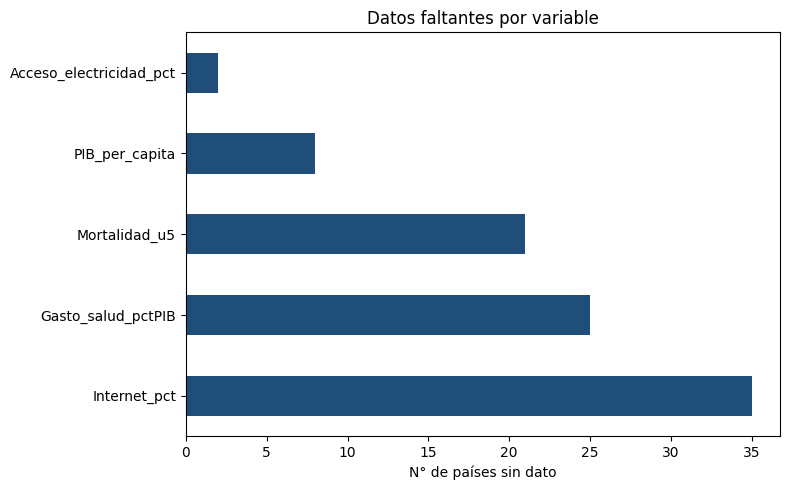

In [36]:
faltantes = df.isna().sum().sort_values(ascending=False)
print(faltantes)
faltantes[faltantes > 0].plot(kind="barh", color="#1F4E78")
plt.title("Datos faltantes por variable")
plt.xlabel("N° de países sin dato")
plt.tight_layout(); plt.show()

Observamos la distribución de las covariables no monetarias con histogramas.

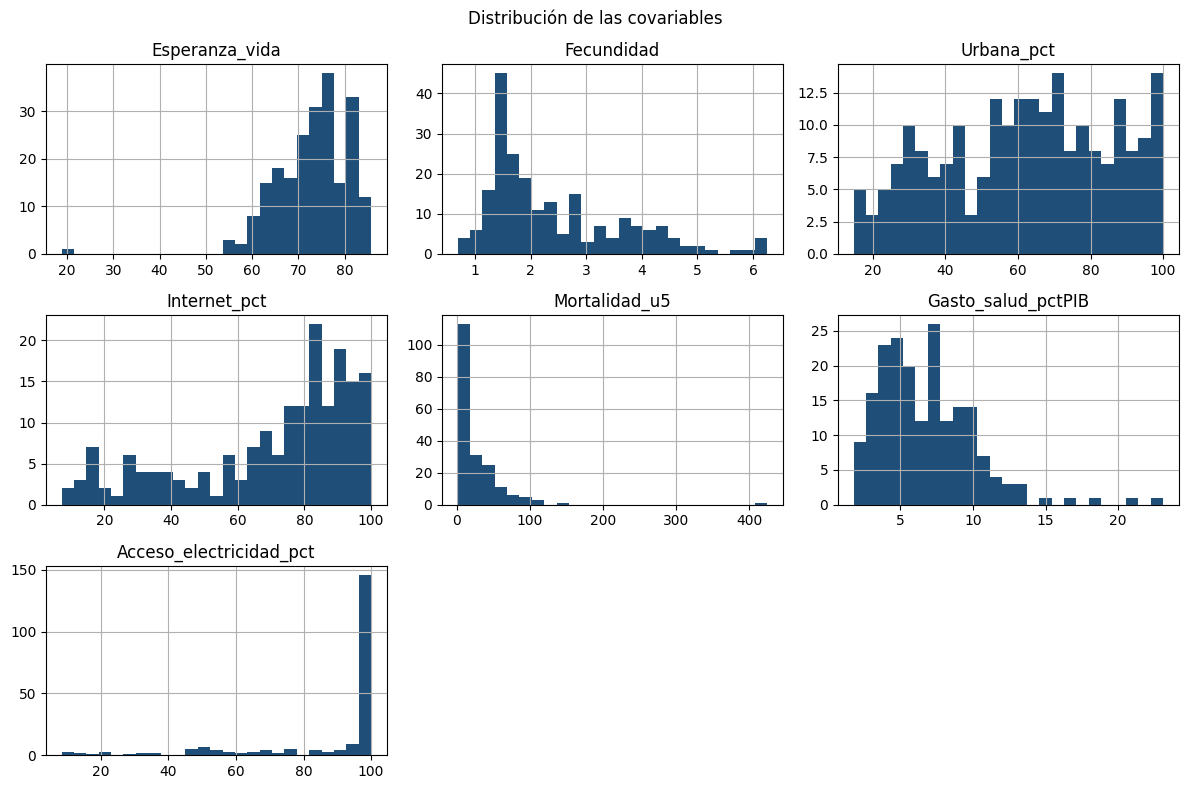

In [37]:
covariables = ["Esperanza_vida", "Fecundidad", "Urbana_pct", "Internet_pct",
               "Mortalidad_u5", "Gasto_salud_pctPIB", "Acceso_electricidad_pct"]
df[covariables].hist(bins=25, figsize=(12, 8), color="#1F4E78")
plt.suptitle("Distribución de las covariables")
plt.tight_layout(); plt.show()

Luego, se revisan las correlaciones entre las covariables para anticipar redundancias.

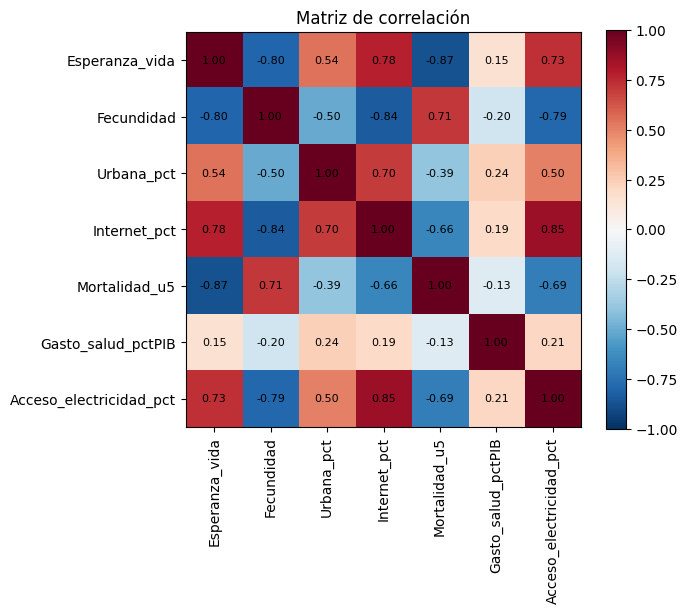

In [38]:
corr = df[covariables].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(covariables))); ax.set_xticklabels(covariables, rotation=90)
ax.set_yticks(range(len(covariables))); ax.set_yticklabels(covariables)
for i in range(len(covariables)):
    for j in range(len(covariables)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im); plt.title("Matriz de correlación"); plt.tight_layout(); plt.show()

Se revisan los valores atípicos con diagramas de caja sobre las covariables estandarizadas, para poder compararlas en una misma escala.

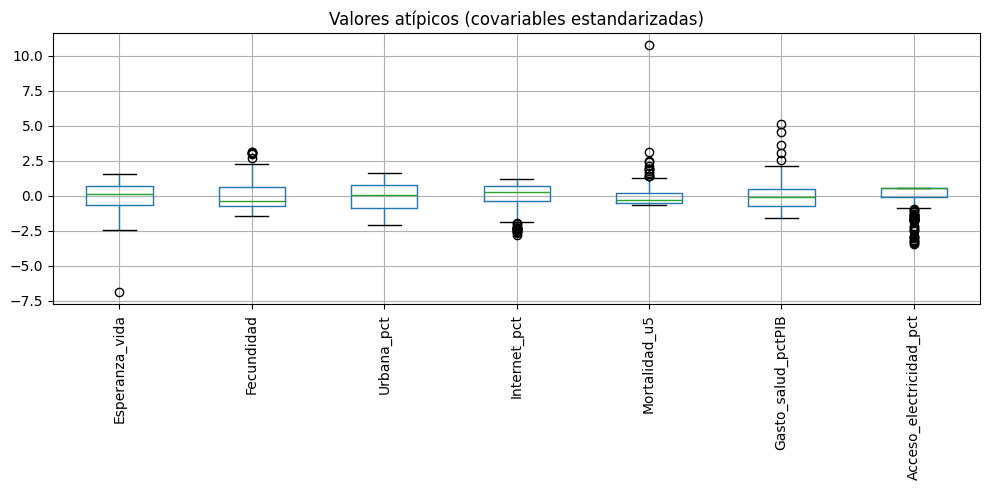

In [39]:
from sklearn.preprocessing import StandardScaler as _SS
Z = pd.DataFrame(_SS().fit_transform(df[covariables].fillna(df[covariables].median())),
                 columns=covariables)
Z.boxplot(rot=90, figsize=(10, 5))
plt.title("Valores atípicos (covariables estandarizadas)")
plt.tight_layout(); plt.show()

### Tratamiento de datos faltantes

Dado que los datos faltantes son pocos y se concentran en el gasto en salud, el uso de internet y la mortalidad, y que el objetivo no es imputar con precisión sino tener una tabla completa para modelar, se imputa cada covariable con su mediana, que es robusta frente a los atípicos que vi arriba.

In [40]:
df[covariables] = df[covariables].fillna(df[covariables].median())
print("Faltantes en covariables tras imputar:", int(df[covariables].isna().sum().sum()))

Faltantes en covariables tras imputar: 0


## 4. Aprendizaje supervisado

### Variable respuesta

El nivel de ingreso oficial tiene cuatro categorías.
- High income : 86 países
- Upper middle income : 59 países
- Lower middle income : 47 países
- Low income : 25 países


Se optó por una clasificación binaria debido al fuerte desbalance existente entre las categorías originales y porque el interés analítico del estudio se centra en identificar los países que alcanzan el nivel de ingreso alto frente a aquellos que no lo alcanzan.

In [41]:
df["y"] = (df["Ingreso_id"] == "HIC").astype(int)
print(df["y"].value_counts())
print("\nProporción de ingreso alto:", round(df["y"].mean(), 3))

y
0    131
1     86
Name: count, dtype: int64

Proporción de ingreso alto: 0.396


Se realiza separación de dataset en entrenamiento y prueba de forma estratificada en la variable "y", para conservar la proporción de clases, y se estandarizan las covariables ajustando el escalador solo con el entrenamiento.

In [42]:
X = df[covariables]
y = df["y"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (151, 7)  Test: (66, 7)


Se entrenaron cuatro modelos de clasificación, realizando validación cruzada en con 5-kfold.

Se realiza balanceo de clases con `class_weight='balanced'` en 3 de 4 modelos, solo "Gradient Boosting" no lo permite.

Posteriormente, se comparan distintas metricas del modelo, siempre trabajando con el grupo de entrenamiento y el uso de kfold.

In [43]:
modelos = {
    "Regresión logística": LogisticRegression(max_iter=1000,class_weight="balanced"),
    "Árbol de decisión": DecisionTreeClassifier(max_depth=4,class_weight="balanced",random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

# Se definen parametros para validación cruzada
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

filas = []
for nombre, modelo in modelos.items():
    # Predicciones out-of-fold sobre el conjunto de entrenamiento
    pred_cv = cross_val_predict(modelo,X_train_s,y_train,cv=cv,method="predict")
    # Probabilidades out-of-fold
    proba_cv = cross_val_predict(modelo,X_train_s,y_train,cv=cv,method="predict_proba")[:, 1]
    filas.append({
        "Modelo": nombre,
        "Exactitud": accuracy_score(y_train, pred_cv),
        "Exactitud balanceada": balanced_accuracy_score(y_train, pred_cv),
        "Precisión": precision_score(y_train, pred_cv),
        "Recall": recall_score(y_train, pred_cv),
        "F1": f1_score(y_train, pred_cv),
        "ROC-AUC": roc_auc_score(y_train, proba_cv),
    })

resultados = (pd.DataFrame(filas).set_index("Modelo").sort_values("F1", ascending=False))

resultados

#Pendiente sacar metricas con promedio de kfold

,Exactitud,Exactitud balanceada,Precisión,Recall,F1,ROC-AUC
Modelo,,,,,,
Random Forest,0.87,0.86,0.86,0.82,0.84,0.95
Gradient Boosting,0.85,0.84,0.82,0.78,0.80,0.92
Regresión logística,0.83,0.84,0.74,0.88,0.80,0.93
Árbol de decisión,0.79,0.79,0.73,0.77,0.75,0.84


Considernado los calculos de las metricas, se construyen y comparan las curvas ROC de los modelos.

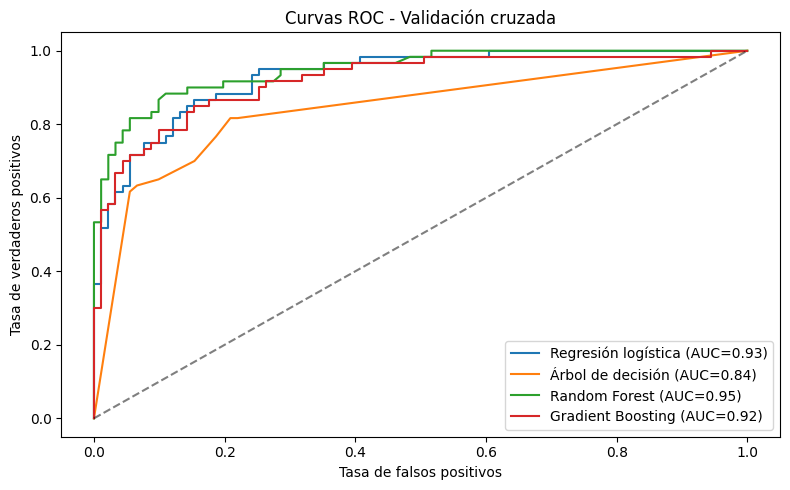

In [44]:
plt.figure()

for nombre, modelo in modelos.items():

    # Probabilidades out-of-fold sobre el conjunto de entrenamiento
    proba_cv = cross_val_predict(modelo,X_train_s,y_train,cv=cv,method="predict_proba")[:, 1]
    fpr, tpr, _ = roc_curve(y_train, proba_cv)
    auc = roc_auc_score(y_train, proba_cv)
    plt.plot(fpr,tpr,label=f"{nombre} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC - Validación cruzada")
plt.legend()
plt.tight_layout()
plt.show()

### Selección del mejor modelo

Elegimos el modelo con mejor F1, que equilibra precisión y recall bajo el desbalance de clases. Se muestra su matriz de confusión y su reporte de clasificación.

In [46]:
mejor_nombre = resultados.index[0]
mejor = modelos[mejor_nombre]

# Ajuste definitivo del mejor modelo usando todo el conjunto de entrenamiento
mejor.fit(X_train_s, y_train)

print("Mejor modelo:", mejor_nombre)

Mejor modelo: Random Forest


### Probabilidad de corte óptima

El umbral por defecto es 0.5. Busco el corte que maximiza el índice de Youden sobre la curva ROC, es decir el punto que mejor separa ambas clases, y vuelvo a evaluar el modelo con ese umbral.

In [47]:
proba_test = mejor.predict_proba(X_test_s)[:, 1]

pred_test_opt = (proba_test >= corte).astype(int)

print("\nMatriz de confusión - Test con umbral óptimo:\n",
      confusion_matrix(y_test, pred_test_opt))

print("\nClassification Report - Test con umbral óptimo:\n",
      classification_report(
          y_test,
          pred_test_opt,
          target_names=["Resto", "Ingreso alto"]
      ))


Matriz de confusión - Test con umbral óptimo:
 [[33  7]
 [ 3 23]]

Classification Report - Test con umbral óptimo:
               precision    recall  f1-score   support

       Resto       0.92      0.82      0.87        40
Ingreso alto       0.77      0.88      0.82        26

    accuracy                           0.85        66
   macro avg       0.84      0.85      0.84        66
weighted avg       0.86      0.85      0.85        66



### Variables más influyentes

Reviso qué covariables pesan más en la predicción, según la importancia del modelo elegido.

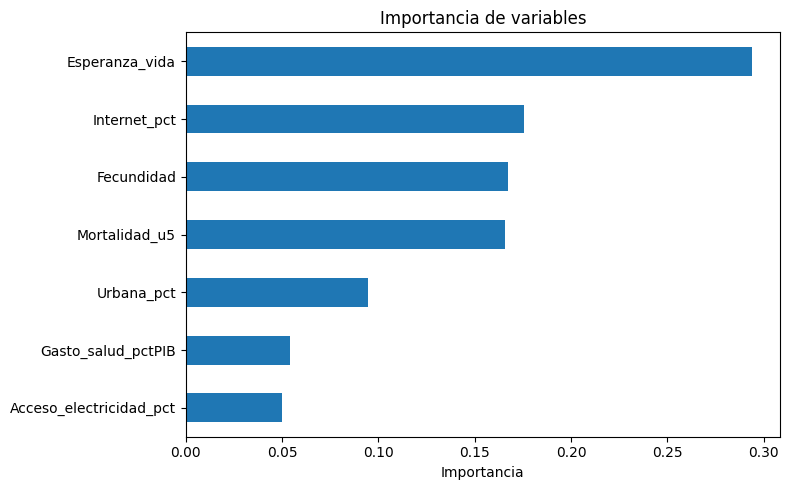

In [48]:
if hasattr(mejor, "feature_importances_"):
    imp = pd.Series(mejor.feature_importances_,index=covariables)
    titulo = "Importancia de variables"
else:
    imp = pd.Series(np.abs(mejor.coef_[0]),index=covariables)
    titulo = "Peso de variables (|coef| regresión logística)"

imp.sort_values().plot(kind="barh")

plt.title(titulo)
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

### Validación de modelo con grupo test

Por ultimo, revisamos las metricas, matriz de validación y variables mas representativas para el grupo test.



In [51]:
# Probabilidades para Test
proba_test = mejor.predict_proba(X_test_s)[:, 1]

# Predicción con umbral 0.5
pred_test_05 = (proba_test >= 0.5).astype(int)

# Predicción con umbral óptimo obtenido en Train
pred_test_opt = (proba_test >= corte).astype(int)

metricas_test = pd.DataFrame({
    "Métrica": [
        "Exactitud",
        "Exactitud balanceada",
        "Precisión",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Umbral 0.5": [
        accuracy_score(y_test, pred_test_05),
        balanced_accuracy_score(y_test, pred_test_05),
        precision_score(y_test, pred_test_05),
        recall_score(y_test, pred_test_05),
        f1_score(y_test, pred_test_05),
        roc_auc_score(y_test, proba_test)
    ],
    "Umbral óptimo": [
        accuracy_score(y_test, pred_test_opt),
        balanced_accuracy_score(y_test, pred_test_opt),
        precision_score(y_test, pred_test_opt),
        recall_score(y_test, pred_test_opt),
        f1_score(y_test, pred_test_opt),
        roc_auc_score(y_test, proba_test)
    ]
})

metricas_test["Umbral 0.5"] = metricas_test["Umbral 0.5"].round(3)
metricas_test["Umbral óptimo"] = metricas_test["Umbral óptimo"].round(3)

metricas_test

,Métrica,Umbral 0.5,Umbral óptimo
0,Exactitud,0.85,0.85
1,Exactitud balanceada,0.83,0.85
2,Precisión,0.86,0.77
3,Recall,0.73,0.89
4,F1,0.79,0.82
5,ROC-AUC,0.92,0.92


Revisamos que tan bien clasifica

In [56]:
# Predicciones sobre el conjunto de prueba
pred_test = mejor.predict(X_test_s)

print("\nMatriz de confusión - Test:\n",
      confusion_matrix(y_test, pred_test))

print("\nClassification Report - Test:\n",
      classification_report(
          y_test,
          pred_test,
          target_names=["Resto", "Ingreso alto"]
      ))


Matriz de confusión - Test:
 [[37  3]
 [ 8 18]]

Classification Report - Test:
               precision    recall  f1-score   support

       Resto       0.82      0.93      0.87        40
Ingreso alto       0.86      0.69      0.77        26

    accuracy                           0.83        66
   macro avg       0.84      0.81      0.82        66
weighted avg       0.84      0.83      0.83        66



In [57]:
print("Classification Report - Test con umbral óptimo\n")

print(
    classification_report(
        y_test,
        pred_test_opt,
        target_names=["Resto", "Ingreso alto"]
    )
)

Classification Report - Test con umbral óptimo

              precision    recall  f1-score   support

       Resto       0.92      0.82      0.87        40
Ingreso alto       0.77      0.88      0.82        26

    accuracy                           0.85        66
   macro avg       0.84      0.85      0.84        66
weighted avg       0.86      0.85      0.85        66



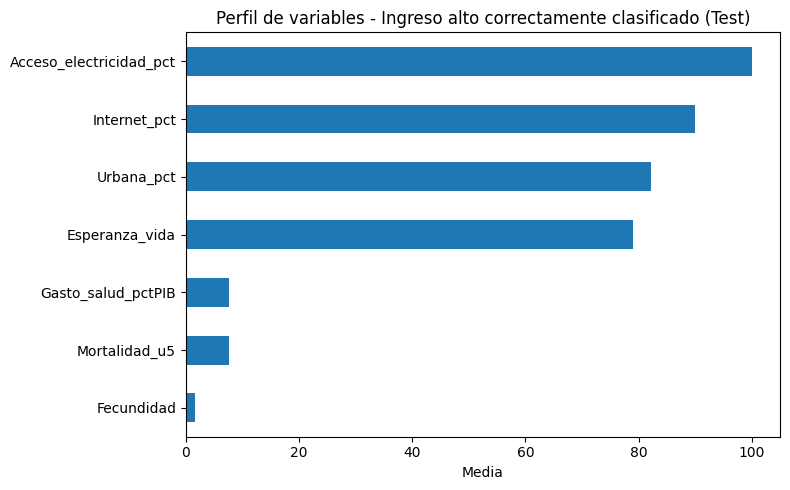

In [66]:
test_tp = test_resultados[
    test_resultados["Resultado"] == "Verdadero positivo"
].copy()

perfil_test = (
    test_tp[covariables]
    .mean()
    .sort_values(ascending=False)
)

perfil_test.sort_values().plot(kind="barh")

plt.title("Perfil de variables - Ingreso alto correctamente clasificado (Test)")
plt.xlabel("Media")
plt.tight_layout()
plt.show()

### Comparativa Train vs Test

In [60]:
# Métricas Train usando el umbral óptimo
proba_train = mejor.predict_proba(X_train_s)[:, 1]
pred_train_opt = (proba_train >= corte).astype(int)

metricas_comparacion = pd.DataFrame({
    "Métrica": [
        "Exactitud",
        "Exactitud balanceada",
        "Precisión",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Train": [
        accuracy_score(y_train, pred_train_opt),
        balanced_accuracy_score(y_train, pred_train_opt),
        precision_score(y_train, pred_train_opt),
        recall_score(y_train, pred_train_opt),
        f1_score(y_train, pred_train_opt),
        roc_auc_score(y_train, proba_train)
    ],

    "Test": [
        accuracy_score(y_test, pred_test_opt),
        balanced_accuracy_score(y_test, pred_test_opt),
        precision_score(y_test, pred_test_opt),
        recall_score(y_test, pred_test_opt),
        f1_score(y_test, pred_test_opt),
        roc_auc_score(y_test, proba_test)
    ]
})

metricas_comparacion["Diferencia Train-Test"] = (
    metricas_comparacion["Train"] -
    metricas_comparacion["Test"]
)

metricas_comparacion.iloc[:, 1:] = metricas_comparacion.iloc[:, 1:].round(3)

metricas_comparacion

,Métrica,Train,Test,Diferencia Train-Test
0,Exactitud,0.94,0.85,0.09
1,Exactitud balanceada,0.95,0.85,0.10
2,Precisión,0.87,0.77,0.10
3,Recall,1.00,0.89,0.12
4,F1,0.93,0.82,0.11
5,ROC-AUC,1.00,0.92,0.09


## 5. Aprendizaje no supervisado

Ahora agrupo los países usando solo las covariables, sin la variable de ingreso. Estandarizo todas las covariables porque el clúster trabaja con distancias.

In [ ]:
Xc = StandardScaler().fit_transform(df[covariables])

### Cantidad de grupos

Elijo el número de grupos combinando dos criterios, el método del codo sobre la inercia y el coeficiente de silueta.

In [ ]:
inercias, siluetas, ks = [], [], range(2, 11)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xc)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(Xc, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inercias, "o-"); ax[0].set_title("Método del codo")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inercia")
ax[1].plot(list(ks), siluetas, "o-", color="green"); ax[1].set_title("Coeficiente de silueta")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silueta")
plt.tight_layout(); plt.show()

El codo y la silueta sugieren una cantidad reducida de grupos. Ajusto K-means con el k elegido y también muestro un dendrograma del clúster jerárquico como respaldo visual.

In [ ]:
K = 3
km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(Xc)
df["Cluster"] = km.labels_

Z = linkage(Xc, method="ward")
plt.figure(figsize=(12, 4))
dendrogram(Z, no_labels=True, color_threshold=0)
plt.title("Dendrograma (clúster jerárquico, Ward)")
plt.tight_layout(); plt.show()

Proyecto los países en dos dimensiones con PCA para visualizar los grupos.

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Xc)
plt.figure()
sc = plt.scatter(coords[:, 0], coords[:, 1], c=df["Cluster"], cmap="viridis", alpha=0.8)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
plt.title("Países proyectados con PCA, coloreados por clúster")
plt.colorbar(sc, label="Clúster"); plt.tight_layout(); plt.show()

### Descripción de los grupos

Describo cada clúster por el promedio de sus indicadores, incluyendo el PIB per cápita solo para caracterizarlos.

In [ ]:
perfil = df.groupby("Cluster")[covariables + ["PIB_per_capita"]].mean()
perfil["N_paises"] = df.groupby("Cluster").size()
perfil.T

### Contraste con la clasificación oficial de ingreso

Cruzo los grupos obtenidos con el nivel de ingreso del Banco Mundial. Aquí es donde aparece la información no evidente, los países que caen en un clúster que no corresponde al cajón donde los pone su nivel de ingreso.

In [ ]:
tabla = pd.crosstab(df["Cluster"], df["Ingreso"])
tabla

In [ ]:
# Ejemplos de países cuyo perfil los acerca a un grupo distinto al de su ingreso
resumen = df[["Ingreso", "Cluster", "PIB_per_capita", "Esperanza_vida", "Internet_pct"]]
resumen.sort_values(["Cluster", "Ingreso"]).head(20)

## 6. Conclusiones

_(Redactar a partir de los resultados. Ideas para desarrollar.)_

- Qué indicadores no monetarios resultaron más determinantes para separar a los países de ingreso alto del resto, y qué dice eso sobre lo que acompaña al desarrollo económico más allá del PIB.
- Qué tan bien predice el mejor modelo y qué aportó ajustar la probabilidad de corte.
- Cuántos perfiles de países emergieron del clúster y en qué se diferencian.
- Dónde el agrupamiento por datos coincidió con la clasificación oficial de ingreso y en qué casos no, relacionándolo con la pregunta y los objetivos iniciales.

## Bibliografía

Banco Mundial. (2024). *World Development Indicators* \[Base de datos\]. https://data.worldbank.org

_(Completar con formato APA las demás fuentes citadas en el texto.)_